# Smart Grid Energy Forecasting Using LSTM

# 1. Introduction




### 1.1 Project Overview



Electricity demand forecasting is essential for efficient power management in smart grids. This project predicts hourly electricity demand using a deep learning model (LSTM) and compares it with a traditional statistical model (ARIMA).

1.2 Objectives

Predict hourly electricity demand

Implement LSTM deep learning model

Implement ARIMA forecasting model

Compare forecasting performance

#2. Dataset Description

### 2.1 Dataset Source

Dataset used: Hourly Energy Consumption Dataset (Kaggle)

File used: PJMW_hourly.csv

### 2.2 Dataset Features
| Column   | Description                     |
| -------- | ------------------------------- |
| Datetime | Timestamp of electricity demand |
| PJMW_MW  | Electricity demand in megawatts |


# 3. System Implementation

### 3.1 Import Required Libraries

In [ ]:
!pip install statsmodels

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

from statsmodels.tsa.arima.model import ARIMA

### 3.2 Load the Dataset

In [ ]:
data = pd.read_csv('energy.csv')

print(data.head())

In [ ]:
!unzip project.zip

Archive:  project.zip
  inflating: AEP_hourly.csv          
  inflating: COMED_hourly.csv        
  inflating: DAYTON_hourly.csv       
  inflating: DEOK_hourly.csv         
  inflating: DOM_hourly.csv          
  inflating: DUQ_hourly.csv          
  inflating: EKPC_hourly.csv         
  inflating: FE_hourly.csv           
  inflating: NI_hourly.csv           
  inflating: PJME_hourly.csv         
  inflating: PJMW_hourly.csv         
  inflating: PJM_Load_hourly.csv     
  inflating: est_hourly.paruqet      
  inflating: pjm_hourly_est.csv      


In [ ]:
import pandas as pd
data = pd.read_csv("/content/PJMW_hourly.csv")
data.head()

,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077.0
1,2002-12-31 02:00:00,4939.0
2,2002-12-31 03:00:00,4885.0
3,2002-12-31 04:00:00,4857.0
4,2002-12-31 05:00:00,4930.0


### 3.3 Data Preprocessing

In [ ]:
data['Datetime'] = pd.to_datetime(data['Datetime'])
data.set_index('Datetime', inplace=True)

In [ ]:
data.index = pd.to_datetime(data.index)
data = data.sort_index()

In [ ]:
data = data[~data.index.duplicated(keep='first')]

### 3.4 Electricity Demand Visualization

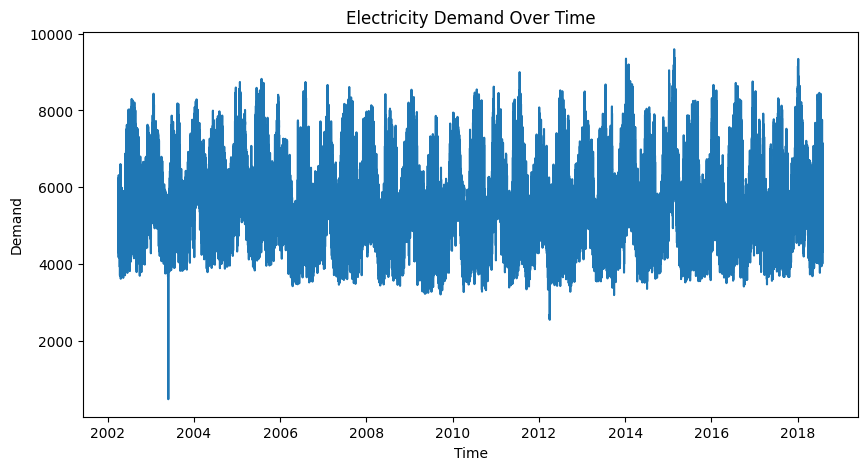

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(data['PJMW_MW'])
plt.title("Electricity Demand Over Time")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.show()

### 3.5 Data Normalization

In [ ]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data[['PJMW_MW']])

### 3.6 Create Time Series Dataset

In [ ]:
def create_dataset(dataset, time_step=10):
    X, Y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        Y.append(dataset[i+time_step, 0])
    return np.array(X), np.array(Y)

time_step = 10

X, y = create_dataset(scaled_data, time_step)

X = X.reshape(X.shape[0], X.shape[1], 1)

### 3.7 Prepare Training Data
### 3.8 Train-Test Data Split

In [ ]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

### 3.9 LSTM Model Architecture

In [ ]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(10,1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 10, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

### 3.10 Model Training

In [ ]:
history = model.fit(X_train, y_train,
                    validation_data=(X_test,y_test),
                    epochs=20,
                    batch_size=32)

Epoch 1/20
3580/3580 ━━━━━━━━━━━━━━━━━━━━ 42s 11ms/step - loss: 0.0072 - val_loss: 1.7422e-04
Epoch 2/20
3580/3580 ━━━━━━━━━━━━━━━━━━━━ 37s 10ms/step - loss: 2.6239e-04 - val_loss: 1.7272e-04
Epoch 3/20
3580/3580 ━━━━━━━━━━━━━━━━━━━━ 37s 10ms/step - loss: 2.4072e-04 - val_loss: 1.8277e-04
Epoch 4/20
3580/3580 ━━━━━━━━━━━━━━━━━━━━ 42s 10ms/step - loss: 2.3913e-04 - val_loss: 1.6430e-04
Epoch 5/20
3580/3580 ━━━━━━━━━━━━━━━━━━━━ 37s 10ms/step - loss: 2.0793e-04 - val_loss: 1.5960e-04
Epoch 6/20
3580/3580 ━━━━━━━━━━━━━━━━━━━━ 37s 10ms/step - loss: 1.9143e-04 - val_loss: 1.5095e-04
Epoch 7/20
3580/3580 ━━━━━━━━━━━━━━━━━━━━ 36s 10ms/step - loss: 1.8041e-04 - val_loss: 1.5360e-04
Epoch 8/20
3580/3580 ━━━━━━━━━━━━━━━━━━━━ 44s 11ms/step - loss: 1.8016e-04 - val_loss: 1.4713e-04
Epoch 9/20
3580/3580 ━━━━━━━━━━━━━━━━━━━━ 37s 10ms/step - loss: 1.7985e-04 - val_loss: 1.4245e-04
Epoch 10/20
3580/3580 ━━━━━━━━━━━━━━━━━━━━ 37s 10ms/step - loss: 1.7820e-04 - val_loss: 1.4705e-04
Epoch 11/20
3580/3580 ━

### 3.11 Generate LSTM Predictions

In [ ]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

895/895 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step


### 3.12 ARIMA Model Implementation

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(data['PJMW_MW'], order=(5,1,0))

arima_result = arima_model.fit()

forecast = arima_result.forecast(steps=50)

print(forecast.head())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


143202    5232.196122
143203    5079.033088
143204    4994.521030
143205    5002.453948
143206    5086.571005
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


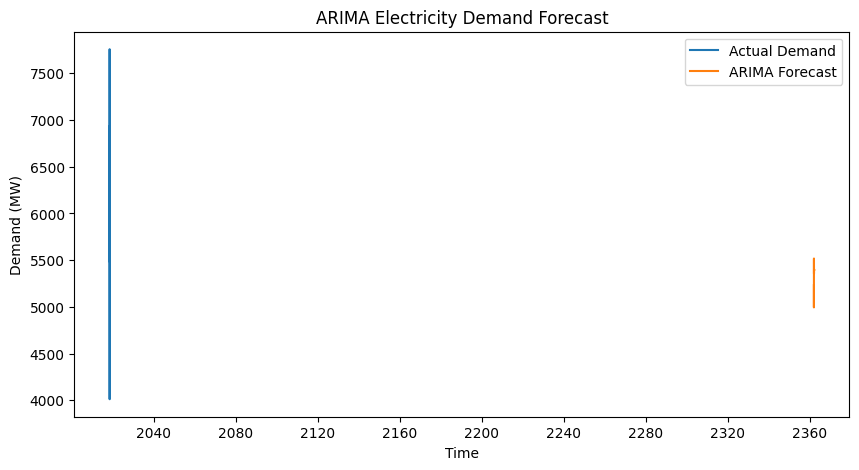

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# last 200 actual values
plt.plot(data['PJMW_MW'][-200:], label="Actual Demand")

# ARIMA forecast
plt.plot(range(len(data)-1, len(data)-1 + len(forecast)), forecast, label="ARIMA Forecast")

plt.title("ARIMA Electricity Demand Forecast")
plt.xlabel("Time")
plt.ylabel("Demand (MW)")
plt.legend()

plt.show()

# 4. Model Evaluation

### 4.1 Performance Metrics

Calculate RMSE and MAE to evaluate model accuracy.

In [ ]:
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, predictions))
mae_lstm = mean_absolute_error(y_test_actual, predictions)

print("LSTM RMSE:", rmse_lstm)
print("LSTM MAE:", mae_lstm)

LSTM RMSE: 107.22735958025646
LSTM MAE: 80.22113357427263


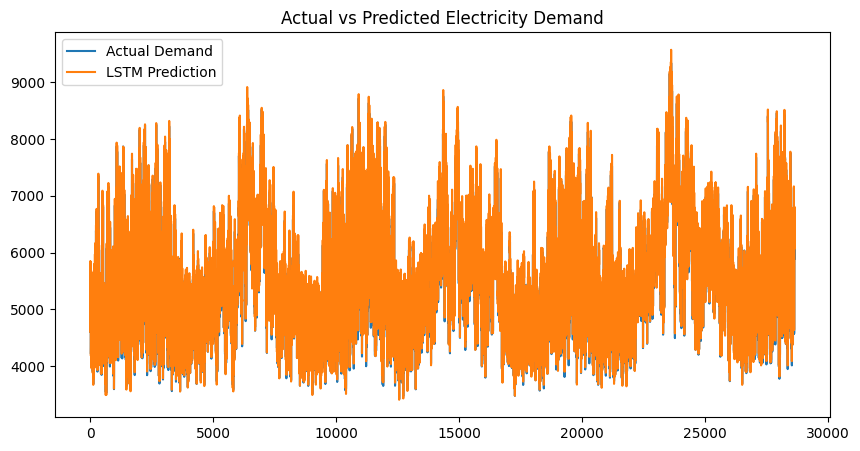

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(y_test_actual, label="Actual Demand")
plt.plot(predictions, label="LSTM Prediction")

plt.legend()
plt.title("Actual vs Predicted Electricity Demand")
plt.show()

# 5. Conclusion

The results show that the LSTM model provides better forecasting accuracy compared to ARIMA, as it captures complex patterns and long-term dependencies in electricity demand data.

# 6. Future Work



*  Integrate weather data into forecasting models

*  Implement advanced deep learning architectures such as Transformers

*   Deploy real-time forecasting systems for smart grids
